In [1]:
import pandas as pd


In [2]:
# from datasets import load_dataset

# dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_All_Beauty", trust_remote_code=True)
# data = dataset['full'].to_pandas()


# data = pd.read_csv("datasets/datafiniti/consumer-reviews-of-amazon-products/versions/5/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")
# print(data.head())

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

data = pd.read_json("datasets/All_Beauty.jsonl", lines=True)

In [4]:
data.drop(columns=['images', 'asin', 'parent_asin', 'user_id','timestamp',], inplace=True)
data = data.dropna()
missing_counts = data.isna().sum()
print(missing_counts)

rating               0
title                0
text                 0
helpful_vote         0
verified_purchase    0
dtype: int64


In [5]:
ratings_map = {5:2,4:2,3:1,2:0,1:0}
data['rating_sentiment'] = data['rating'].map(ratings_map)
print(data.head())
# data.groupby('rating_sentiment')['reviews.doRecommend'].mean().plot(kind='bar')


   rating                                      title  \
0       5  Such a lovely scent but not overpowering.   
1       4     Works great but smells a little weird.   
2       5                                       Yes!   
3       1                          Synthetic feeling   
4       5                                         A+   

                                                text  helpful_vote  \
0  This spray is really nice. It smells really go...             0   
1  This product does what I need it to do, I just...             1   
2                          Smells good, feels great!             2   
3                                     Felt synthetic             0   
4                                            Love it             0   

   verified_purchase  rating_sentiment  
0               True                 2  
1               True                 2  
2               True                 2  
3               True                 0  
4               True                 

In [6]:
print((data['rating_sentiment'] == 2).sum())
print((data['rating_sentiment'] == 1).sum())
print((data['rating_sentiment'] == 0).sum())

min = min([(data['rating_sentiment'] == 2).sum(), (data['rating_sentiment'] == 1).sum(), (data['rating_sentiment'] == 1).sum()])
print(min)

500107
56307
145114
56307


In [7]:
df_pos = data[data['rating_sentiment'] == 2].sample(n=min, random_state=42) # Reduce 942 to min
df_neu = data[data['rating_sentiment'] == 1].sample(n=min, random_state=42)
df_neg = data[data['rating_sentiment'] == 0].sample(n=min, random_state=42)

df_balanced = pd.concat([df_pos, df_neu, df_neg])

print((df_balanced['rating_sentiment'] == 2).sum())
print((df_balanced['rating_sentiment'] == 1).sum())
print((df_balanced['rating_sentiment'] == 0).sum())

56307
56307
56307


In [8]:
# total_samples = neg_count + neu_count + pos_count
# w_neg = total_samples / (3 * neg_count)
# w_neu = total_samples / (3 * neu_count)
# w_pos = total_samples / (3 * pos_count)
# weights = torch.tensor([w_neg, w_neu, w_pos])

print(data.columns)


Index(['rating', 'title', 'text', 'helpful_vote', 'verified_purchase',
       'rating_sentiment'],
      dtype='object')


In [9]:
from sklearn.model_selection import train_test_split
X=df_balanced.drop(columns=['rating', 'helpful_vote', 'verified_purchase', 'rating_sentiment'])
y=df_balanced["rating_sentiment"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_val.shape}")
print(f"Training output size: {y_train.shape}")
print(f"Testing output size: {y_val.shape}")

print(type(X_train))

Training set size: (135136, 2)
Testing set size: (33785, 2)
Training output size: (135136,)
Testing output size: (33785,)
<class 'pandas.core.frame.DataFrame'>


In [10]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Load Tokenizer and Model
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
# num_labels=2 for binary classification (Real vs Fake)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=3)


train_dataset = Dataset.from_pandas(X_train.assign(label=y_train))
val_dataset = Dataset.from_pandas(X_val.assign(label=y_val))
# 2. Convert your DataFrame to Hugging Face Dataset format
# train_dataset = Dataset.from_pandas(X_train, preserve_index=False)
# val_dataset = Dataset.from_pandas(X_val, preserve_index=False)

print(train_dataset[0])

# 3. Tokenization Function
def tokenize_function(examples):
    return tokenizer(examples["text"],
                     examples["title"],
                     padding="max_length",
                     truncation=True,
                     max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

print(tokenized_train[0])

# 4. Define Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,              # 3 epochs is usually enough for fine-tuning
    eval_strategy='epoch',      # Evaluate after each epoch
    learning_rate=2e-5,              # Crucial: use a very small learning rate for fine-tuning
    weight_decay=0.01,
)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}
# 5. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'title': 'Best ever', 'text': 'Awesome price', 'label': 2, '__index_level_0__': 629009}


Map:   0%|          | 0/135136 [00:00<?, ? examples/s]

Map:   0%|          | 0/33785 [00:00<?, ? examples/s]

{'title': 'Best ever', 'text': 'Awesome price', 'label': 2, '__index_level_0__': 629009, 'input_ids': [101, 12476, 3976, 102, 2190, 2412, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [11]:
# 6. Start Fine-Tuning
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.437762,0.441128,0.825455
2,0.371843,0.469569,0.827764
3,0.310196,0.539194,0.828741


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=50676, training_loss=0.3929493838096533, metrics={'train_runtime': 6738.1207, 'train_samples_per_second': 60.166, 'train_steps_per_second': 7.521, 'total_flos': 1.3426075219304448e+16, 'train_loss': 0.3929493838096533, 'epoch': 3.0})

In [12]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.5391944050788879, 'eval_accuracy': 0.8287405653396478, 'eval_runtime': 133.4567, 'eval_samples_per_second': 253.153, 'eval_steps_per_second': 31.651, 'epoch': 3.0}


In [13]:
# Get raw predictions
predictions = trainer.predict(tokenized_val)

# Convert raw numbers (logits) to class labels (0, 1, or 2)
predicted_labels = np.argmax(predictions.predictions, axis=1)

# # Compare them to the real labels
# true_labels = predictions.label_ids


# Your code here :
from sklearn.metrics import accuracy_score

# print(accuracy_score(y_trainset, y_train_pred))

NameError: name 'y_testset' is not defined

In [15]:
print(accuracy_score(y_val, predicted_labels))

0.8287405653396478


In [20]:
from transformers import pipeline

# Create a classification pipeline using your trained model and tokenizer
# If you didn't save it yet, use trainer.model and trainer.tokenizer
my_test_pipeline = pipeline("sentiment-analysis", model=trainer.model, tokenizer=tokenizer)

# Try a positive review
print(my_test_pipeline("This tablet is amazing, the battery lasts forever!"))

# Try a negative review
print(my_test_pipeline("I hate this product, it broke after two days."))

# Try a neutral review
print(my_test_pipeline("This product is Ok. it works"))

[{'label': 'LABEL_2', 'score': 0.9990047812461853}]
[{'label': 'LABEL_0', 'score': 0.9952848553657532}]
[{'label': 'LABEL_1', 'score': 0.9002794027328491}]


In [ ]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)


final_acc = accuracy_score(y_val, predicted_labels)

print(f'Final Accuracy  : {final_acc:.4f}  ({final_acc*100:.2f}%)')
print(classification_report(y_val, predicted_labels))

print('\nConfusion Matrix:')
print(confusion_matrix(y_val, predicted_labels))

Final Accuracy  : 0.8287  (82.87%)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82     11417
           1       0.75      0.75      0.75     11219
           2       0.92      0.91      0.92     11149

    accuracy                           0.83     33785
   macro avg       0.83      0.83      0.83     33785
weighted avg       0.83      0.83      0.83     33785


Confusion Matrix:
[[ 9377  1958    82]
 [ 1987  8439   793]
 [   79   887 10183]]


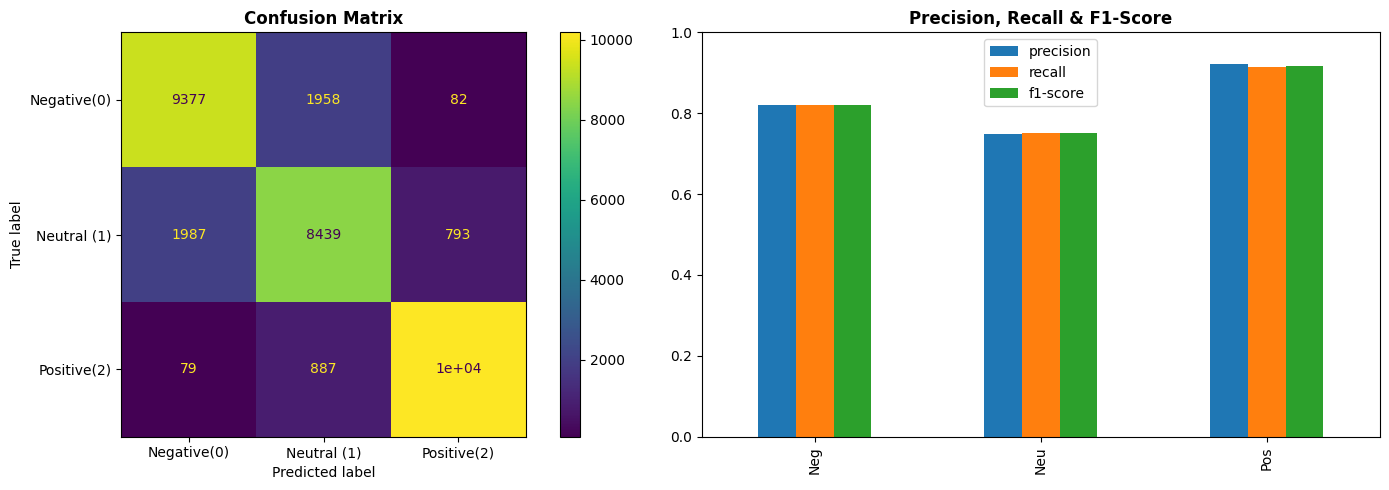

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_val, predicted_labels),
    display_labels=['Negative(0)', 'Neutral (1)', "Positive(2)"]
).plot(ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')

report = classification_report(y_val, predicted_labels,
                               target_names=['Neg', 'Neu', 'Pos'], output_dict=True)

# Plotting precision, recall, and f1-score on the second axis
pd.DataFrame(report).iloc[:-1, :3].T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Precision, Recall & F1-Score', fontweight='bold')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


This model uses a larger data set and 2 tokens(review and title). The samples for each class were equilized to the min sample size. As seen from results above the accuracy has reduced compared to the prev acc of 95%(small dataset) but we have increased the accuracy compared to our other model(larger dataset) and the individual accuracy for the classes.


now we can change the params to achieve better accuracy

In [19]:
import os
working_dir = './'
output_directory = os.path.join(working_dir, "Review Senses 3.0")
model_save_path = os.path.join(output_directory, "Sentiment Analyzer")
trainer.model.save_pretrained(model_save_path)
tokenizer.save_pretrained(output_directory, "Sentiment Analyzer")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./Review Senses 3.0/tokenizer_config.json',
 './Review Senses 3.0/tokenizer.json')